In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# import scipy.signal
import numpy as np
import scipy
from scipy import signal
import matplotlib.pyplot as plt

In [3]:
from sonar import sonar
import torch

Creating a circle

In [4]:
plt.figure(figsize=[5,5])

def create_mat(radius=20,size=500):
    span = np.linspace(-1,1,size)
    X,Y = np.meshgrid(span,span)
    
    cone = 1-(X**2+Y**2)**0.5
    
    return (cone>(1-(radius/size*2)))


<Figure size 500x500 with 0 Axes>

Create kernenls, perform convolution

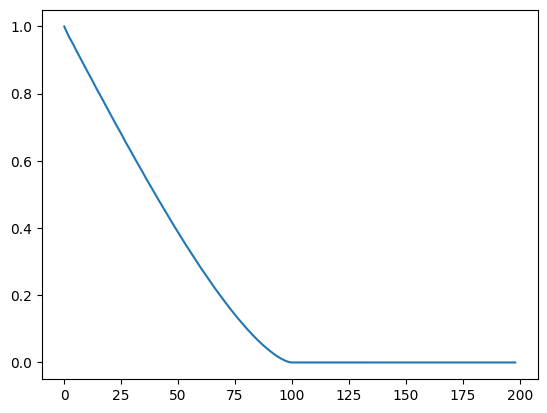

In [5]:

showcase1=[]
rad_ = 200
a_masks = []
a_conv = []
rad_cell=50
conveds = []

mat = create_mat(radius=rad_cell,size=1000)

for r in range(1,rad_):
#     plt.subplot(6,7,r)
    rad = r
    # mat = np.roll(mat,200,0)+np.roll(create_mat(radius=rad_cell-25,size=1000),-200,0)
    kernel=(create_mat(radius=rad, size=rad_*2+1)^create_mat(radius=rad-1,size=rad_*2+1))
    conved = signal.fftconvolve(mat,kernel,mode='same')
    conveds.append(conved.copy())
    a_conv.append(conved.sum())
    showcase1.append((conved*mat).sum()/conved.sum())
    a_masks.append(kernel.sum())
    
plt.plot(showcase1)
showcase1=np.array(showcase1)
showcase1=np.array(showcase1)
a_masks=np.array(a_masks)
a_conv =np.array(a_conv)
conveds = np.array(conveds)


Cheking kernels and convolution

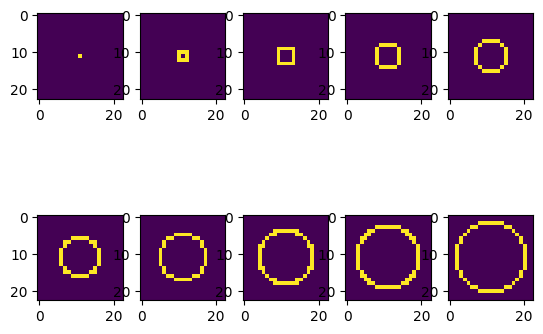

In [6]:
rad_ = 11
for r in range(1,rad_):
    plt.subplot(2,5,r)
    rad = r
    kernel=(create_mat(radius=rad, size=rad_*2+1)^create_mat(radius=rad-1,size=rad_*2+1))
    plt.imshow(kernel)

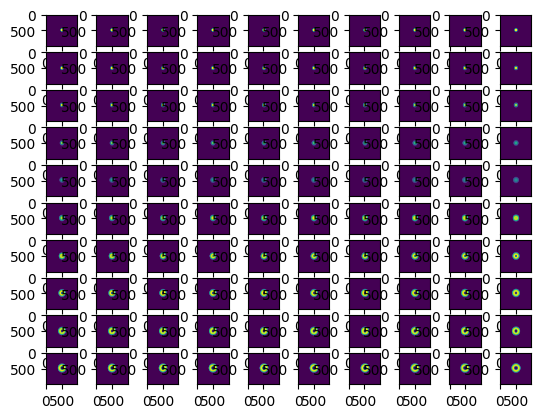

In [7]:
rad_ = 101
a_masks = []
a_conv = []
rad_cell=50
conveds = []

for r in range(1,rad_):
    plt.subplot(10,10,r)
    rad = r
    kernel=(create_mat(radius=rad, size=rad_*2+1)^create_mat(radius=rad-1,size=rad_*2+1))
    conved = signal.fftconvolve(mat,kernel,mode='same')
    conveds.append(conved.copy())
    plt.imshow(conved)

Showcase 0, single circle. Using sonar

(2, 600, 600)


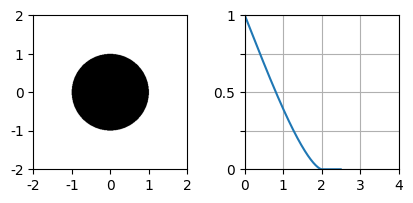

In [8]:
plt.figure(figsize=[5,2])

showcase0=[]
rad_ = 250
rad_cell=100
conveds = []
total_size=600

mat = np.array([create_mat(radius=rad_cell,size=total_size)])
mat = np.concatenate([mat,1-mat],axis=0)
print(mat.shape)


son = sonar.Sonar(max_radius=rad_, linear_radius_steps=rad_)
#radii, 
co_occurrence = son.co_occurrence_from_tensor(hists=mat)#, interpolate=True)
showcase0 = co_occurrence[0,0].flatten()#/son.kernel_areas[::-1]

plt.subplot(1,2,1)
plt.imshow(mat[0].squeeze(),cmap='Greys')
    
xlox = np.linspace(0,600,7)
xtix = [str(int(i)) for i in (xlox-300)/100]
plt.xticks(xlox,xtix)    
plt.yticks(xlox,xtix)    
# plt.title('A circular structure with unit radius:')
plt.xlim(total_size//2-(rad_cell*2),total_size//2+(rad_cell*2))
plt.ylim(total_size//2-(rad_cell*2),total_size//2+(rad_cell*2))

ax = plt.subplot(1,2,2)
plt.plot(showcase0)

xlox = np.arange(0,rad_,rad_cell//2)
xtix = xlox/rad_cell
plt.xticks(xlox,xtix)    

ylox = np.linspace(0,1,5)
ytix = ['0','','0.5','','1',]
plt.yticks(ylox,ytix)    
plt.ylim(0,1)

plt.xlim(0,4*rad_cell)
xticks = np.arange(0,rad_cell*4+1,rad_cell)
plt.xticks(xticks,xticks//rad_cell)
plt.grid()

aspect = np.subtract(*ax.get_xlim())/np.subtract(*ax.get_ylim())
ax.set_aspect(aspect)   


plt.savefig('./output/unit_circle.svg')

(-x*sqrt(4 - x**2) + 4*acos(x/2))/(2*pi)

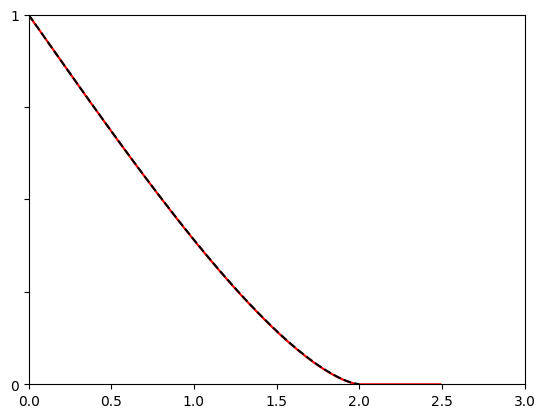

In [9]:
import sympy as sp 

x,y,r = sp.symbols('x y r')

semi_circle = sp.sqrt(1**2-x**2)

auto_cooc_x = (-2 * (x/2) * sp.sqrt(1 - (x/2)**2/(r)**2) + 2 * r * sp.acos((x/2)/(r)) )/ (sp.pi * r )
plt.plot(son.radii[:-1]/rad_cell,co_occurrence[0,0].flatten(),color='r')


cooc_modeled = [auto_cooc_x.subs(r,1).subs(x,l) for l in  np.linspace(0,2,50)]
plt.plot(np.linspace(0,2,50),cooc_modeled,linestyle='--',color='black')
plt.xlim(0,3)
ylox = np.linspace(0,1,5)
ytix = ['0','','','','1',]
plt.yticks(ylox,ytix)    
plt.ylim(0,1)

sp.simplify(auto_cooc_x.subs(r,1))

<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in divide
  return 2*r*arccos((1/2)*(r**2 + x**2 - 1)/(r*x))


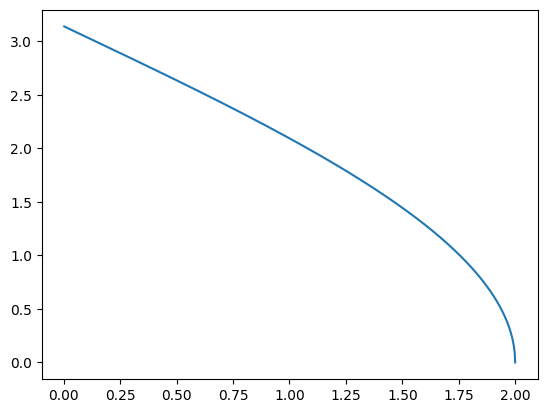

In [10]:
from scipy.signal import convolve
from scipy.fft import fft 

x,r = sp.symbols('x r')

carc = (2*r*sp.acos( (r**2 + x**2 -1)/(2*r*x)))

carc_lambda = sp.lambdify([x,r],carc)

# sp.integrate(carc.subs(r,2),x)

r_ = 1.0
x = np.linspace(r_-1,r_+1,1000)

carc_evaluated = carc_lambda(x,r_)
plt.plot(x,(carc_evaluated))

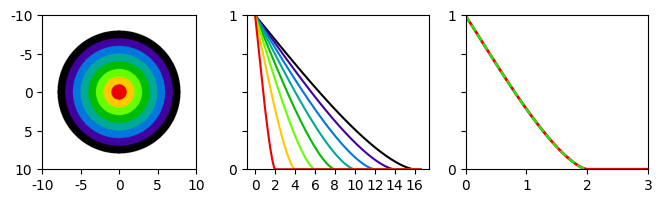

In [11]:
from matplotlib.cm import nipy_spectral

plot_mat = np.zeros((total_size,total_size,4))

test_radii = np.arange(30,251,30)[::-1]
son = sonar.Sonar(max_radius=rad_*2, linear_radius_steps=rad_*2,)

plt.figure(figsize=(8,2))

ax1 = plt.subplot(1,3,2)
xlox = np.arange(0,rad_*2,60)
xtix = xlox//30
plt.xticks(xlox,xtix)    

ylox = np.linspace(0,1,5)
ytix = ['0','','','','1',]
plt.yticks(ylox,ytix)    
plt.ylim(0,1)

for i,r in enumerate(test_radii):
    color = nipy_spectral(i/len(test_radii))
    mat = np.array([create_mat(radius=r,size=total_size)])
    plot_mat[mat[0]>0] = color
    mat = np.concatenate([mat,1-mat],axis=0)
    
    co_occurrence = son.co_occurrence_from_tensor(hists=mat,memory_efficient=True)
    ax1.plot(co_occurrence[0,0].flatten(),color=color)
    
ax2 = plt.subplot(1,3,1)
plt.imshow(plot_mat)

xtix = np.linspace(0,total_size,5).astype(int)
plt.xticks(xtix,(xtix-total_size//2)//30)
plt.yticks(xtix,(xtix-total_size//2)//30)
ax3 = plt.subplot(1,3,3)

plt.plot(son.radii[:-1]/30,co_occurrence[0,0].flatten(),color=color,linewidth=2)
plt.plot(np.linspace(0,2,50),cooc_modeled,linestyle='--',color='lime')
plt.xlim(0,3)
ylox = np.linspace(0,1,5)
ytix = ['0','','','','1',]
plt.yticks(ylox,ytix)    
plt.ylim(0,1)

plt.savefig('./output/unit_circle_multiparam.svg',dpi=600)


Showcase 1. A boolean noise: p(x=1)=0.5. Using sonar

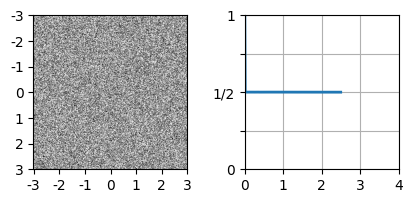

In [12]:
plt.figure(figsize=[5,2])


showcase1=[]
rad_ = 250
rad_cell=100
conveds = []
total_size=600

mat = np.random.random([1,total_size,total_size])>0.5#create_mat(radius=rad_cell,size=600)
mat = np.concatenate([mat,1-mat],axis=0)


son = sonar.Sonar(max_radius=rad_, linear_radius_steps=rad_,edge_correction=True)
#radii, 
co_occurrence = son.co_occurrence_from_tensor(hists=mat)
showcase1 = co_occurrence[0,0].flatten()#/son.kernel_areas[::-1]


plt.subplot(1,2,1)
plt.imshow(mat.argmax(0),cmap='Greys')
    
xlox = np.linspace(0,total_size,7)
xtix = [str(int(i)) for i in (xlox-300)/100]
plt.xticks(xlox,xtix)    
plt.yticks(xlox,xtix)    
# plt.title('boolean noise: x~Bernoulli(0.5)')


ax=plt.subplot(1,2,2)
plt.plot(showcase1,linewidth=2)

xlox = np.arange(0,rad_,rad_cell//2)
xtix = xlox/rad_cell
plt.xticks(xlox,xtix)    
# plt.title('Derived autocorrelation curve:')

ylox = np.linspace(0,1,5)
ytix = ['0','','1/2','','1',]
plt.yticks(ylox,ytix)    
plt.ylim(0,1)

# plt.vlines([rad_cell,rad_cell*2],0,showcase0.max(),alpha=0.5)
plt.xlim(0,4*rad_cell)
xticks = np.arange(0,rad_cell*4+1,rad_cell)
plt.xticks(xticks,xticks//rad_cell)
plt.grid()

aspect = np.subtract(*ax.get_xlim())/np.subtract(*ax.get_ylim())
ax.set_aspect(aspect)  

plt.savefig('./output/noise_05.svg')

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_868223/3472042633.py:24: SyntaxWarning: invalid escape sequence '\l'
  plt.plot([0,0.05,5],[1,1-l,1-l],c=nipy_spectral((i)/(len(lambdas))*1.1),label=f'$\lambda$={l}')


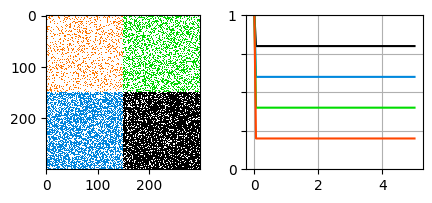

In [13]:
from matplotlib.cm import nipy_spectral

lambdas = [0.2,0.4,0.6,0.8]

plt.figure(figsize=[5,2])

plot_mats = []# = np.zeros((total_size,total_size,4))

for i in range(len(lambdas)):
    mat = np.random.random([1,total_size//4,total_size//4])[0]<lambdas[i]
    plot_mats.append(mat*(i+1))

plot_mat = np.concatenate(( np.concatenate((plot_mats[0],plot_mats[2])),np.concatenate((plot_mats[1],plot_mats[3]))),axis=1).astype(float)
plot_mat[plot_mat==0]=np.nan


ax1 = plt.subplot(121)
plt.imshow(plot_mat, cmap='nipy_spectral_r', interpolation='none',vmin=0.3,vmax=4)

ax2 = plt.subplot(122)

for i in range(len(lambdas)):
    l = lambdas[i]
    plt.plot([0,0.05,5],[1,1-l,1-l],c=nipy_spectral((i)/(len(lambdas))*1.1),label=f'$\lambda$={l}')
    
plt.grid()
ylox = np.linspace(0,1,5)
ytix = ['0','','','','1',]
plt.yticks(ylox,ytix)    
plt.ylim(0,1)

plt.savefig('./output/noise_multiparam.svg',dpi=600)

Showcase 2. A boolean noise: p(x=1)=0.1. Using sonar

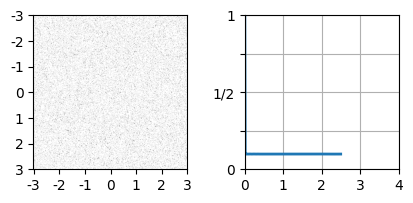

In [14]:
plt.figure(figsize=[5,2])


showcase2=[]
rad_ = 250
rad_cell=100
conveds = []
total_size=600

mat = np.random.random([1,total_size,total_size])<0.1#create_mat(radius=rad_cell,size=600)
mat = np.concatenate([mat,1-mat],axis=0)


son = sonar.Sonar(max_radius=rad_, linear_radius_steps=rad_,edge_correction=True)
#radii, 
co_occurrence = son.co_occurrence_from_tensor(hists=mat)
showcase2 = co_occurrence[0,0].flatten()#/son.kernel_areas[::-1]


plt.subplot(1,2,1)
plt.imshow(mat[0],cmap='Greys')
    
xlox = np.linspace(0,total_size,7)
xtix = [str(int(i)) for i in (xlox-300)/100]
plt.xticks(xlox,xtix)    
plt.yticks(xlox,xtix)    
# plt.title('boolean noise: x~Bernoulli(0.1)')


ax=plt.subplot(1,2,2)
plt.plot(showcase2,linewidth=2)

xlox = np.arange(0,rad_,rad_cell//2)
xtix = xlox/rad_cell
plt.xticks(xlox,xtix)    
# plt.title('Derived autocorrelation curve:')

ylox = np.linspace(0,1,5)
ytix = ['0','','1/2','','1',]
plt.yticks(ylox,ytix)    
plt.ylim(0,1)

# plt.vlines([rad_cell,rad_cell*2],0,showcase0.max(),alpha=0.5)
plt.xlim(0,4*rad_cell)
xticks = np.arange(0,rad_cell*4+1,rad_cell)
plt.xticks(xticks,xticks//rad_cell)
plt.grid()

aspect = np.subtract(*ax.get_xlim())/np.subtract(*ax.get_ylim())
ax.set_aspect(aspect) 

plt.savefig('./output/noise_01.svg') 

Showcase 3. A circle + boolean noise. Using sonar

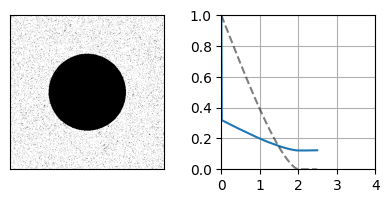

In [15]:
plt.figure(figsize=[5,2])

showcase3=[]
rad_ = 250
rad_cell=100
conveds = []
total_size=1000

ftr = np.random.random([total_size,total_size])>0.1
mat = create_mat(radius=rad_cell,size=total_size)
surf = mat.sum()
mat[ftr<0.1] = 1
mat=np.array([mat])
mat = np.concatenate([mat,1-mat],axis=0)

son = sonar.Sonar(max_radius=rad_, linear_radius_steps=rad_,circumference_normalization=True,edge_correction=True)
#radii, 
co_occurrence = son.co_occurrence_from_tensor(hists=mat)
showcase3 = co_occurrence[0,0].flatten()#/son.kernel_areas[::-1]


plt.subplot(1,2,1)
plt.imshow(mat[0].squeeze(),cmap='Greys')

# xlox = np.arange()
xtix = [str(int(i)) for i in (xlox-300)/100]
plt.xticks(xlox,xtix)    
plt.yticks(xlox,xtix)    
# plt.title('Circle $\cup$ 10% noise')

plt.xlim(total_size//2-rad_cell*2,total_size//2+rad_cell*2)
plt.ylim(total_size//2-rad_cell*2,total_size//2+rad_cell*2)


ax1 = plt.subplot(1,2,2)

plt.plot(showcase3)
plt.plot(showcase0,'k',linestyle='dashed',alpha=0.5)
xlox = np.arange(0,rad_,rad_cell//2)
xtix = xlox/rad_cell
plt.xticks(xlox,xtix)    
# plt.title('Derived autocorrelation curve:')

# ylox = np.linspace(0.15,0.25,7)
# ytix = ['0.15','','','0.20','','','0.25',]

# plt.yticks(ylox,ytix)    
# plt.xlabel('units')
plt.xlim(0,4*rad_cell)
plt.ylim(0,1)
xticks = np.arange(0,rad_cell*4+1,rad_cell)
plt.xticks(xticks,xticks//rad_cell)
plt.grid()

aspect = np.subtract(*ax1.get_xlim())/np.subtract(*ax1.get_ylim())
ax1.set_aspect(aspect)  

plt.savefig('./output/noise_circle.svg')

Elipsoid. Skipped

In [ ]:
# plt.figure(figsize=[16,5])


# def create_oval_mat(radius=20,size=500):
#     span = np.linspace(-1,1,size)
#     X,Y = np.meshgrid(span,span)
    
#     cone = 1-((2*X)**2+(Y/2)**2)**0.5
    
#     return (cone>(1-(radius/size*2)))

# showcase1=[]
# rad_ = 250
# rad_cell=100
# conveds = []

# mat = np.array([create_oval_mat(radius=rad_cell,size=600)])

# # for r in range(1,rad_):

# #     rad = r
    
# #     kernel=(create_mat(radius=rad, size=rad_*2+1)^create_mat(radius=rad-1,size=rad_*2+1))
# #     kernel=kernel/kernel.sum()
# #     conved = scipy.signal.fftconvolve(mat,kernel,mode='same')

# #     plot1.append((conved*mat).sum())
    
    
# son = sonar.Sonar()
# son.run_pipeline(cell_matrix=mat,max_radius=rad_, plot=False)
# dm = son.distance_maps

# showcase1 = dm.flatten()/son.kernel_areas[::-1]
# mat=mat.squeeze()

    
# showcase1=np.array(showcase1)

# plt.subplot(1,3,1)
# plt.imshow(mat,cmap='Greys')
    
# xlox = np.linspace(0,600,7)
# xtix = [str(int(i)) for i in (xlox-300)/100]
# plt.xticks(xlox,xtix)    
# plt.yticks(xlox,xtix)    

# plt.title('An oval structure with unit radius:')

# plt.subplot(1,3,2)
# plt.plot(showcase1)
# plt.plot(showcase0,'k',linestyle='dashed',alpha=0.5)
# xlox = np.arange(0,rad_,rad_cell//2)
# xtix = xlox/rad_cell
# plt.xticks(xlox,xtix)    

# plt.title('Derived autocorrelation curve:')

# ylox = np.arange(0,mat.sum(),mat.sum()//12)
# ytix = ['0','','','1/2','','','1',]
# # ytix = [str(i)+' $\pi$' for i in np.arange(0,13)/12]
# plt.yticks(ylox[::2],ytix)    

# plt.xlabel('radii')
# plt.ylabel('fraction of surface, $\pi$')

# plt.vlines([rad_cell,rad_cell/2,rad_cell*2],0,showcase1.max(),alpha=0.5)

# plt.ylim(0,mat.sum())

# plt.xlim(0,None)

# plt.subplot(1,3,3)
# plt.title('First derivative:')
# diff = np.diff(showcase1)/3
# diff = diff+np.roll(diff,-2,0)+np.roll(diff,-1,0)
# diff[-3:]=diff[-3]
# plt.plot(diff)

# diff = np.diff(showcase0)/3
# diff = diff+np.roll(diff,-2,0)+np.roll(diff,-1,0)
# diff[-3:]=diff[-3]

# plt.plot(diff,'k',linestyle='dashed',alpha=0.5)

# plt.savefig('./output/oval.svg')

Showcase 4. Dots, equally distributed

770

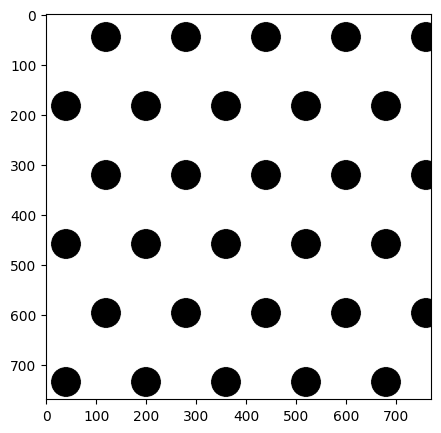

In [145]:
# create a dot matrix

plt.figure(figsize=[16,5])

showcase4=[]
rad_ = 500
rad_cell=30
distance = 160
vertical_shift = int((distance**2-(0.5*distance)**2)**0.5)
total_size=1200
conveds = []

mat = create_mat(radius=rad_cell,size=1200)

mat = np.roll(np.roll(mat,-(total_size//2)+rad_cell),-(total_size//2)+rad_cell,axis=0)

surf = mat.sum()

for i in range(total_size//distance):
    mat = mat+np.roll(mat,distance,1)

mat = mat + np.roll( np.roll(mat,distance//2),vertical_shift,axis=0)

for i in range(total_size//vertical_shift//2):
    mat = mat+np.roll(mat,vertical_shift*2,axis=0)

mat = mat[260:-170,230:-200]
    
mat=np.array([mat]) 

plt.imshow(mat.squeeze(),cmap='Greys')

mat = np.concatenate([mat,1-mat],axis=0)

total_size = mat.shape[-1]

total_size
# kewl

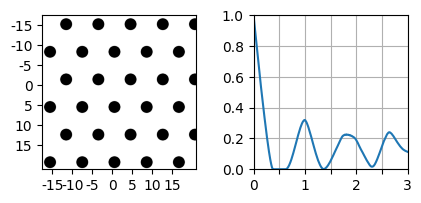

In [146]:
plt.figure(figsize=[5,2])


son = sonar.Sonar(max_radius=rad_, linear_radius_steps=rad_,circumference_normalization=True,edge_correction=True)

co_occurrence = son.co_occurrence_from_tensor(hists=mat,memory_efficient=True)
showcase4 = co_occurrence.flatten()

plt.subplot(1,2,1)
plt.imshow(mat[0].squeeze(),cmap='Greys')
    
xlox = np.linspace(0,700,15)[1::2]
xtix = [int(f) for f in (xlox-350)/20]
plt.xticks(xlox,xtix)    
plt.yticks(xlox,xtix)    

ax = plt.subplot(1,2,2)


xlox = np.arange(0,rad_,distance//2)
xtix = ['0','','1','','2','','3']
plt.xticks(xlox,xtix)    

ylox = np.linspace(0,mat[0].squeeze().sum(),11)

plt.xlim(0,None)
plt.plot(showcase4)     
plt.grid()
plt.ylim(0,1)


aspect = np.subtract(*ax.get_xlim())/np.subtract(*ax.get_ylim())
ax.set_aspect(aspect)  
#    
# plt.vlines(dists,0,showcase4.max(),alpha=0.5,linestyles='dashed',color='grey')
plt.savefig('./output/multi_circles.svg')

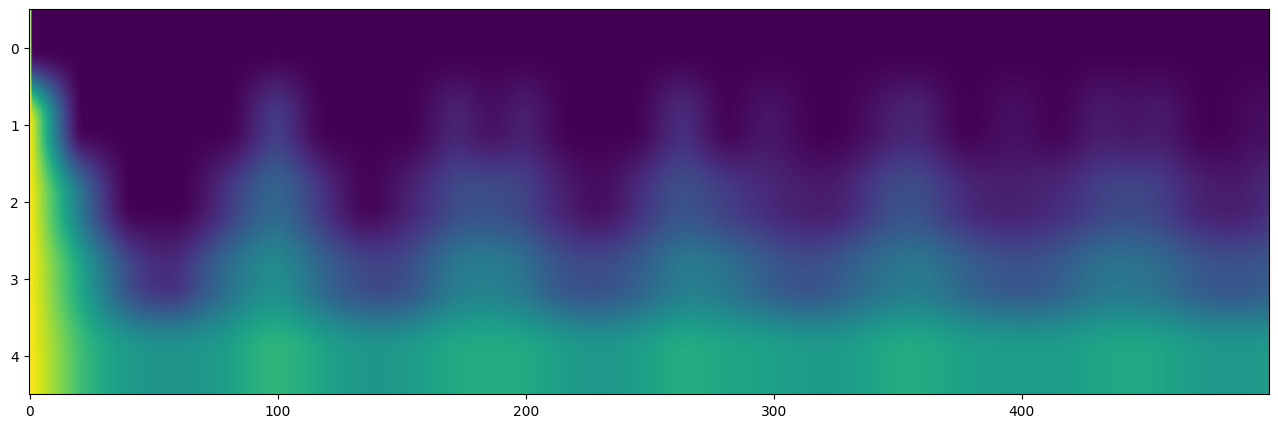

In [147]:
from scipy.signal import fftconvolve

plt.figure(figsize=[16,5])

showcase4=[]
rad_ = 500
rad_cell=10
distance = 100
vertical_shift = int((distance**2-(0.5*distance)**2)**0.5)
total_size=1200
conveds = []

mat = np.zeros((1200,1200))
mat[0,0]=1

mat = np.roll(np.roll(mat,-(total_size//2)+rad_cell),-(total_size//2)+rad_cell,axis=0)

surf = mat.sum()

for i in range(total_size//distance):
    mat = mat+np.roll(mat,distance,1)

mat = mat + np.roll( np.roll(mat,distance//2),vertical_shift,axis=0)

for i in range(total_size//vertical_shift//2):
    mat = mat+np.roll(mat,vertical_shift*2,axis=0)

mat = mat[260:-170,230:-200]
mat_ = mat.clip(0,1)

circle = create_mat(radius=rad_cell,size=rad_cell*2+1)
    
mat = fftconvolve(mat_,circle,mode='same')    
    
mat=np.array([mat]) 

# plt.imshow(mat.squeeze(),cmap='Greys')

mat = np.concatenate([mat,1-mat],axis=0)

total_size = mat.shape[-1]

total_size


showcase4 = []
mats4 = []
for rad_cell in range(1,50,2*5):
    
    circle = create_mat(radius=rad_cell,size=rad_cell*2+1)

    mat = fftconvolve(mat_,circle,mode='same')    
        
    mat=np.array([mat]) 
    mats4.append(mat.copy())

    plt.imshow(mat.squeeze(),cmap='Greys')

    mat = np.concatenate([mat,1-mat],axis=0)

    total_size = mat.shape[-1]

    total_size
    co_occurrence = son.co_occurrence_from_tensor(hists=mat,memory_efficient=True)
    showcase4.append(co_occurrence[0,0].flatten())

plt.imshow(showcase4,aspect='auto')


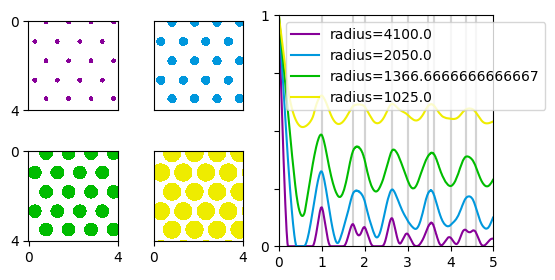

In [148]:
from matplotlib.colors import LinearSegmentedColormap

fig = plt.figure(figsize=[6,3])

colors = [nipy_spectral((i+0.5)/5) for i in range(4)]

plots = [1,2,3,4]#[5,10,15,20]

grid = plt.GridSpec(2, 4, wspace=0.4, hspace=0.3)

ax1 = fig.add_subplot(grid[0,0])
ax1.imshow(mats4[plots[0]][0][:400,:400],cmap=LinearSegmentedColormap.from_list('c0',['w',colors[0]]),interpolation='none')
ax1.set_yticks([0,400],[0,4])
ax1.set_xticks([],[])

ax2 = fig.add_subplot(grid[0,1])
ax2.imshow(mats4[plots[1]][0][:400,:400],cmap=LinearSegmentedColormap.from_list('c1',['w',colors[1]]),interpolation='none',)
ax2.set_yticks([],[])
ax2.set_xticks([],[])


ax3 = fig.add_subplot(grid[1,0])
ax3.imshow(mats4[plots[2]][0][:400,:400],cmap=LinearSegmentedColormap.from_list('c1',['w',colors[2]]),interpolation='none',)
ax3.set_yticks([0,400],[0,4])
ax3.set_xticks([0,400],[0,4])

ax4 = fig.add_subplot(grid[1,1])
ax4.imshow(mats4[plots[3]][0][:400,:400],cmap=LinearSegmentedColormap.from_list('c1',['w',colors[3]]),interpolation='none',)
ax4.set_yticks([],[])
ax4.set_xticks([0,400],[0,4])



ax5 = fig.add_subplot(grid[:,2:])

def hexagonal_s(n,m):
    return (n**2+n*m+m**2)**0.5

for i in range(5):
    for j in range(5):
        plt.vlines(hexagonal_s(i,j),0,1.2,color='lightgrey')
        
ax5.plot(np.arange(len(showcase4[0]))/distance,showcase4[plots[0]],label=f'radius={distance/plots[0]*rad_cell}',color=colors[0])
ax5.plot(np.arange(len(showcase4[0]))/distance,showcase4[plots[1]],label=f'radius={distance/plots[1]*rad_cell}',color=colors[1])
ax5.plot(np.arange(len(showcase4[0]))/distance,showcase4[plots[2]],label=f'radius={distance/plots[2]*rad_cell}',color=colors[2])
ax5.plot(np.arange(len(showcase4[0]))/distance,showcase4[plots[3]],label=f'radius={distance/plots[3]*rad_cell}',color=colors[3])

plt.legend()

ax5.set_yticks(np.linspace(0,1,5),[0,'','','',1])
ax5.set_ylim(0,1)
ax5.set_xlim(0,5)

plt.savefig('./output/multi_circles_compared.svg',dpi=600)

Showcase 5. correlation between different classes

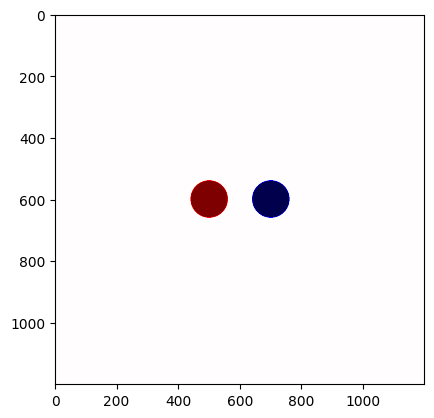

In [21]:
# plt.figure(figsize=[16,5])

showcase5_1=[]
showcase5_2=[]
rad_ = 500
rad_cell=60
distance=100
conveds = []
total_size=1200

mat1 = np.roll(create_mat(radius=rad_cell,size=total_size),-distance,1)
mat2 = np.roll(mat1,distance*2,1)
mat3 = 1-(mat1+mat2)
       
plt.imshow(mat1.astype(int)-mat2,cmap='seismic')

In [22]:
mat_total = np.array([mat1, mat2,mat3], np.int32)
mat_total.shape

(3, 1200, 1200)

In [23]:
son = sonar.Sonar(max_radius=rad_, linear_radius_steps=rad_,edge_correction=True)
#radii, 
co_occurrence_rb = son.co_occurrence_from_tensor(hists=mat_total,memory_efficient=True)


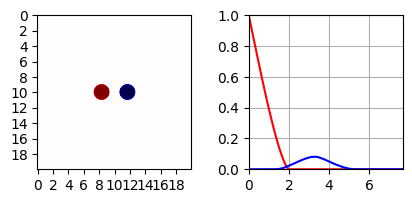

In [24]:
plt.figure(figsize=[5,2])

plt.subplot(121)

xlox = np.arange(0,mat_total.shape[1],rad_cell)
xtix = xlox//rad_cell
plt.xticks(xlox[::2],xtix[::2])    
plt.yticks(xlox[::2],xtix[::2])
plt.imshow(mat1.astype(int)-mat2,cmap='seismic')
# plt.title('2 circles of area $\pi$:')

ax=plt.subplot(122)

plt.plot(co_occurrence_rb[0,0], color = 'red')
plt.plot(co_occurrence_rb[1,0], color = 'blue')

plt.xticks(xlox[::2],xtix[::2])
plt.xlim(0, distance+rad_cell*6)
# plt.title('co-occurrence:')

plt.grid()
plt.ylim(0,1)


aspect = np.subtract(*ax.get_xlim())/np.subtract(*ax.get_ylim())
ax.set_aspect(aspect)  
#    

plt.savefig('./output/two_circles.svg')

In [ ]:
rad_cell=30

son = sonar.Sonar(max_radius=rad_, linear_radius_steps=rad_,edge_correction=False)

co_occurrences_rb = []
mats_rb = []

for distance in range(0,rad_cell*8,rad_cell//2):
    
    mat1 = np.roll(create_mat(radius=rad_cell,size=total_size),-distance,1)
    mat2 = np.roll(mat1,distance*2,1)
    mat3 = 1-((mat1+mat2)>0)

    mat_total = np.array([mat1, mat2,mat3], np.int32)

    co_occurrence_rb = son.co_occurrence_from_tensor(hists=mat_total,memory_efficient=True)
    co_occurrences_rb.append(co_occurrence_rb)
    mats_rb.append(mat_total.copy())
    
co_occurrences_rb = np.array(co_occurrences_rb)


0.0
0.0
1.9
2.933333333333333
4.0
4.966666666666667
6.0
6.966666666666667
8.0
9.0
9.966666666666667
11.0
11.966666666666667
13.0
13.966666666666667
15.0


/tmp/ipykernel_868223/934926146.py:11: RuntimeWarning: divide by zero encountered in divide
  plt.plot(x,16/3/(x*np.pi*2)/np.pi,'--',color='grey')


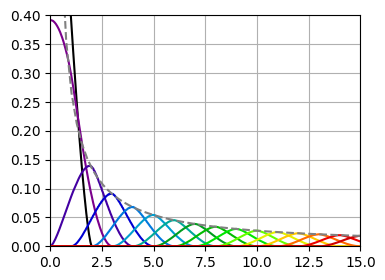

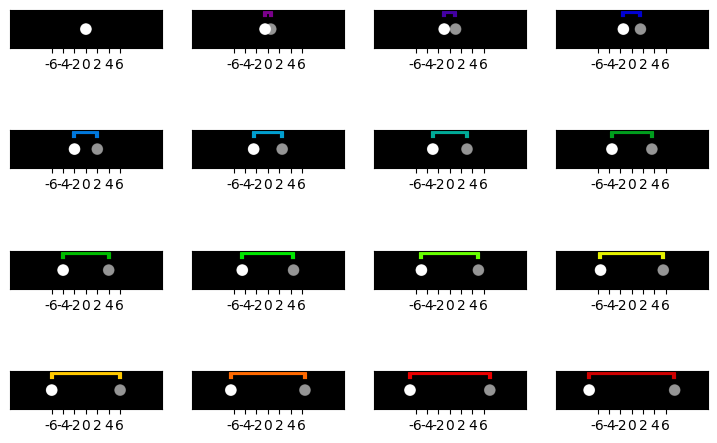

In [26]:
plt.figure(figsize=(4,3 ))


for i in range(co_occurrences_rb.shape[0]):
    color = nipy_spectral(i/co_occurrences_rb.shape[0])
    plt.plot(np.arange(co_occurrences_rb.shape[-1])/rad_cell,co_occurrences_rb[i,0,1], color = color,label=f'{i}')
    print(co_occurrences_rb[i,0,1].argmax()/30)


x=np.linspace(0,15,60)
plt.plot(x,16/3/(x*np.pi*2)/np.pi,'--',color='grey')

# plt.legend(title='distance')
plt.grid()
plt.ylim(0,0.4)
plt.xlim(0,15)

plt.savefig('./output/two_circles_multiparam.svg')

plt.figure(figsize=(9,6))
for i in range(len(mats_rb)):
    color = nipy_spectral(i/co_occurrences_rb.shape[0])
    plt.subplot(4,4,i+1)
    plt.imshow(mats_rb[i].argmax(0),cmap='Greys')
    x_ = 600-i*rad_cell/2
    _x = 600+i*rad_cell/2
    plt.plot([x_,x_,_x,_x],[670,690,690,670],color=color,linewidth=3,)
    plt.ylim(500,700)
    plt.xlim(200,1000)
    plt.xticks(np.linspace(-rad_cell*6,rad_cell*6,7)+600,np.linspace(-rad_cell*6,rad_cell*6,7).astype(int)//rad_cell)#['',-300//rad_cell,'','',0,'','',300//rad_cell,'',])
    plt.yticks([],[])
    


plt.savefig('./output/two_circles_multiparam_mats.svg')

0.0
0.0
1.9
2.933333333333333
4.0
4.966666666666667
6.0
6.966666666666667
8.0
9.0
9.966666666666667
11.0
11.966666666666667
13.0
13.966666666666667
15.0


/tmp/ipykernel_868223/4038892906.py:28: RuntimeWarning: invalid value encountered in multiply
  volume_values = 16 * ((2 - m_values) * E_values - 2 * (1 - m_values) * K_values)


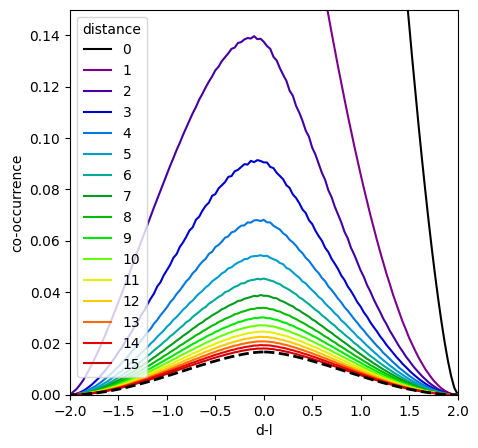

In [27]:
plt.figure(figsize=(5,5 ))


for i in range(co_occurrences_rb.shape[0]):
    color = nipy_spectral(i/co_occurrences_rb.shape[0])
    plt.plot((np.arange(co_occurrences_rb.shape[-1])/rad_cell)-i,co_occurrences_rb[i,0,1], color = color,label=f'{i}')
    print(co_occurrences_rb[i,0,1].argmax()/30)
    
plt.ylim(0,0.15)
plt.xlim(-2,2)

plt.ylabel('co-occurrence')
plt.xlabel('d-l')

from scipy.special import ellipk, ellipe

plt.legend(title='distance')


d_values = np.linspace(0, 1, 500)
m_values = 1 - d_values**2  # m = 1 - d^2

# Calculate the complete elliptic integrals of the first (K) and second (E) kinds
K_values = ellipk(m_values)
E_values = ellipe(m_values)

# Calculate the volume using the provided formula
volume_values = 16 * ((2 - m_values) * E_values - 2 * (1 - m_values) * K_values)


r=rad_cell*2
# plt.plot(co_occurrence_rb[1,0]/co_occurrence_rb[1,0].max(),c='r',linewidth=2)
plt.plot(np.linspace(0,-2,500),volume_values/16/r,c='k',linestyle='--',linewidth=2)
plt.plot(np.linspace(0,2,500),volume_values/16/r,c='k',linestyle='--',linewidth=2)

plt.savefig('./output/two_circles_multiparam_centered.svg')

/tmp/ipykernel_868223/2994980303.py:33: RuntimeWarning: divide by zero encountered in scalar divide
  max_theta = np.arccos(((s**2+d**2-1)/(2*s*d)).clip(-1,None))
<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in sqrt
  return -1/2*sqrt(d**2 - 2*d*l*cos(theta) + l**2)*sqrt(-d**2 + 2*d*l*cos(theta) - l**2 + 4) + 2*arccos((1/2)*sqrt(d**2 - 2*d*l*cos(theta) + l**2))
<lambdifygenerated-3>:2: RuntimeWarning: invalid value encountered in arccos
  return -1/2*sqrt(d**2 - 2*d*l*cos(theta) + l**2)*sqrt(-d**2 + 2*d*l*cos(theta) - l**2 + 4) + 2*arccos((1/2)*sqrt(d**2 - 2*d*l*cos(theta) + l**2))


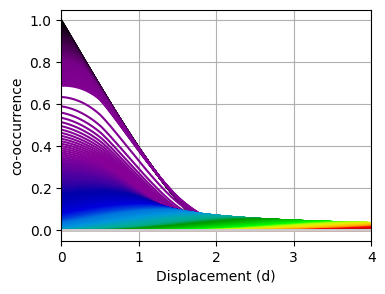

In [51]:
import sympy as sp
import numpy as np

x, s, d_, d, theta, theta0, l = sp.symbols('x s d_ d theta theta_0 l')

# Define symbolic expressions
d_ = sp.sqrt(d**2 + l**2 - 2*d*l*sp.cos(theta))
a = 2*sp.acos(d_/2)-d_/2*sp.sqrt(4-d_**2)
a

# a_function = sp.lambdify([d],a.subs(d,s),'numpy')
# Convert to numerical function with NumPy support
a_function = sp.lambdify([theta,  l, d], a, modules="numpy")
# s_function = sp.lambdify([theta, r, l], s, modules="numpy")


# Define the range of values
ds = np.linspace(0, 6, 800)



ss = np.linspace(0,6,800)
maxs = np.zeros(len(ss))
# # Evaluate the function

plt.figure(figsize=(4,3 ))

for i,s in enumerate(ss):
    
    color = nipy_spectral(i/len(ss))
    
    d=s
    max_theta = np.arccos(((s**2+d**2-1)/(2*s*d)).clip(-1,None))
    thetas = np.linspace(0, max_theta*2, 30)
    
    Thetas, Ds  = np.meshgrid(thetas, ds )
    
    values = np.nan_to_num(a_function(Thetas,s,Ds)).mean(1)/np.pi**2*max_theta
    plt.plot(ds,values,color=color,label=s) # Assuming d=1 for example
    maxs[i]=values.argmax()

# plt.ylim(0,0.4)

x=np.linspace(0,15,60)
# plt.plot(ds,16/3/(ds*np.pi*2)/np.pi,'--',color='grey')

# plt.legend(title='distance')
plt.grid()
plt.xlim(0,4)
plt.ylabel('co-occurrence')
plt.xlabel('Displacement (d)')
plt.savefig('./output/two_circles_multiparam.svg')

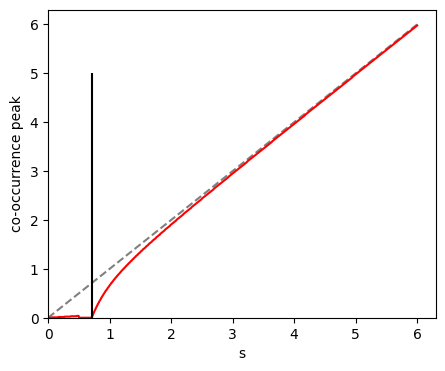

In [30]:
plt.figure(figsize=(5,4 ))

plt.plot(ss,ss,c='grey',linestyle='--')
plt.plot(ss,maxs/800*6,'r')

plt.vlines(1/2**0.5,0,5,color='k')

plt.xlim(0,None)
plt.ylim(0,None)

plt.xlabel('s')
plt.ylabel('co-occurrence peak')

plt.savefig('./output/two_circles_peaks.svg')
 

In [31]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Monte Carlo estimate for co-occurrence probability
# def monte_carlo_co_occurrence(d, l, num_samples=100000):
#     inside_count = 0
    
#     # Generate random points inside the first circle
#     r_s = np.sqrt(np.random.uniform(0, 1, num_samples))  # Uniform in area
#     theta_s = np.random.uniform(0, 2 * np.pi, num_samples)  # Uniform in angle

#     x_s = r_s * np.cos(theta_s)  # Convert to Cartesian
#     y_s = r_s * np.sin(theta_s)

#     # Generate random displacement directions
#     theta_d = np.random.uniform(0, 2 * np.pi, num_samples)
    
#     # Compute displaced positions
#     x_new = x_s + d * np.cos(theta_d)
#     y_new = y_s + d * np.sin(theta_d)
    
#     # Check if new positions are inside the second circle centered at (l, 0)
#     inside_count = np.sum((x_new - l) ** 2 + y_new ** 2 <= 1)
    
#     return inside_count / num_samples

# # Define range of displacement values d and different distances l
# d_values = np.linspace(0, 15, 100)  # Displacement values
# l_values = range(15)  # Different distances between circles

# # Compute probabilities using Monte Carlo simulation
# plt.figure(figsize=(8, 5))
# for l in l_values:
#     color = nipy_spectral(l/co_occurrences_rb.shape[0])
#     p_values = [monte_carlo_co_occurrence(d, l) for d in d_values]
#     print(np.max(p_values)*l)
#     plt.plot(d_values, p_values, label=f'l = {l}',color=color)
    
# x = np.linspace(0,15,100)    
# plt.plot(x,16/3/(x*np.pi*2)/np.pi,'--',color='grey')

# # Plot styling
# plt.xlabel("Displacement (d)")
# plt.ylabel("Co-Occurrence Probability")
# plt.title("Monte Carlo Estimate of Co-Occurrence Probability")
# plt.legend()
# plt.grid(True)
# plt.ylim(0,0.2)
# plt.savefig('./output/monte_carlo_circle_circle.svg')

In [33]:
co_oc2dots = co_occurrence_rb[1,0].flatten()

In [34]:
kernel_array = co_occurrence_rb[1,0].flatten()[90:210]

/tmp/ipykernel_868223/3544822155.py:27: RuntimeWarning: invalid value encountered in multiply
  vol = 16 * ((2 - m_values) * E_values - 2 * (1 - m_values) * K_values)


(100.0, 300.0)

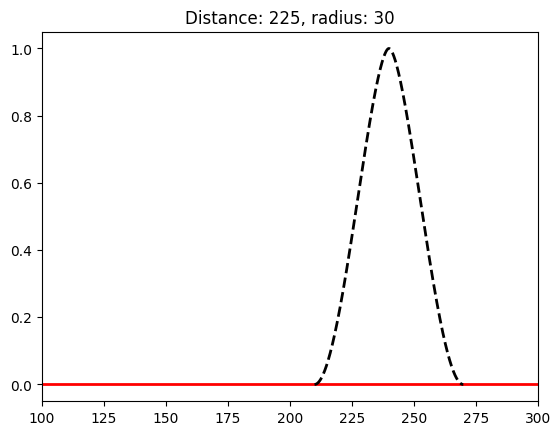

In [35]:
from scipy.signal import convolve,deconvolve

plt.title(f"Distance: {distance}, radius: {rad_cell}")

# R=distance; r=rad_cell*32

# d = np.linspace(0,rad_,rad_)

# I_d = R*2*np.arccos((d**2+R**2-r*2)/(2*d*R))
# I_d[np.isnan(I_d)]=0

# plot = convolve(I_d,I_d[::1],mode='full')
# plt.plot(plot/plot.max(),c='k')
# plt.plot(I_d/I_d.max(),c='lime')

# Define the distance range (d) from 0 to 1 (since intersection only exists when d <= r = 1)

def volume(d_values):
    # d_values = np.linspace(0, 1, 500)
    m_values = 1 - d_values**2  # m = 1 - d^2

    # Calculate the complete elliptic integrals of the first (K) and second (E) kinds
    K_values = ellipk(m_values)
    E_values = ellipe(m_values)

    # Calculate the volume using the provided formula
    vol = 16 * ((2 - m_values) * E_values - 2 * (1 - m_values) * K_values)
    vol[np.isnan(vol)]=np.nanmax(vol)
    vol = np.concatenate([vol[::-1],vol])   
    
    return np.nan_to_num(vol)

volume_values = volume(np.linspace(0,1,500))
# plt.plot(co_occurrence_rb[1,0]/co_occurrence_rb[1,0].max(),c='r',linewidth=2)
plt.plot(co_occurrence_rb[1,0]/co_occurrence_rb[1,0].max(),c='r',linewidth=2)
plt.plot(np.linspace(210,270,1000),volume_values/16,c='k',linestyle='--',linewidth=2)

# plt.plot(co_occurrence_rb[1,0]/co_occurrence_rb[1,0].max(),linestyle='-.',c='b')

plt.xlim(100,300)

/tmp/ipykernel_868223/3654006101.py:13: RuntimeWarning: divide by zero encountered in divide
  I_d = np.arccos((d_**2+rad_kernel**2-(rad_cell)**2)/(2*d_*rad_kernel))/np.pi
/tmp/ipykernel_868223/3654006101.py:13: RuntimeWarning: invalid value encountered in arccos
  I_d = np.arccos((d_**2+rad_kernel**2-(rad_cell)**2)/(2*d_*rad_kernel))/np.pi


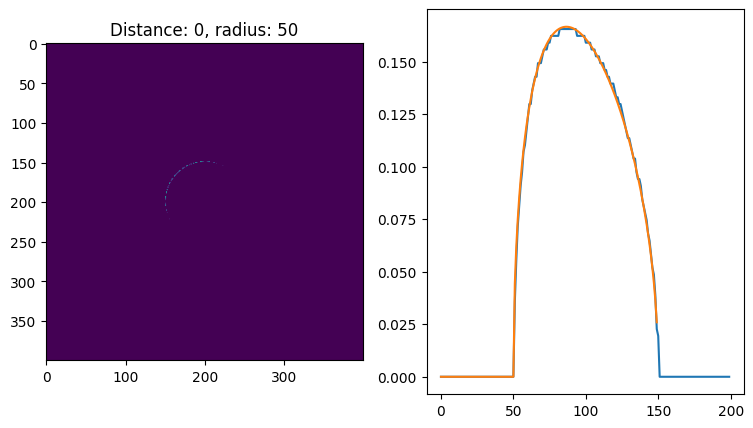

In [41]:
# R=rad_cell*0.1; r=rad_cell*30

rad_cell= 50
distance = 0
rad_kernel= rad_cell*2.0   #kernel radius
# r=
mat_size = 400


d = np.arange(0,distance+(rad_cell*3)) #kernel radii
d_=d

I_d = np.arccos((d_**2+rad_kernel**2-(rad_cell)**2)/(2*d_*rad_kernel))/np.pi
I_d[np.isnan(I_d)]=0
if rad_cell>rad_kernel:
    I_d[:rad_cell-int(rad_kernel)]=1



r=rad_cell
circle = create_mat(radius=rad_cell,size=mat_size).astype(float)
ring = create_mat(radius=rad_kernel+1,size=mat_size).astype(float)-create_mat(radius=rad_kernel,size=mat_size)
ring/=ring.sum()

conved = scipy.signal.fftconvolve(circle,ring,mode='same')

plt.figure(figsize=(9,5))

plt.subplot(121)
plt.title(f"Distance: {distance}, radius: {rad_cell}")

plt.imshow(conved*np.roll(circle,0))

plt.subplot(122)

plt.plot((conved)[mat_size//2:,mat_size//2])

plt.plot(d,I_d)
 

In [43]:
# # x,s = sp.symbols("x s")

# plt.plot(np.linspace(0,-1,500),volume_values/16.2,c='b',linestyle='--')
# plt.plot(np.linspace(0,1,500),volume_values/16.2,c='b',linestyle='--')

# x=np.linspace(-2,2,100)
# s_ = np.linspace(-1,1,40)
# points = []
# for s in s_:

#     y=(1-(x+s)**2)**0.5*(1-(x-s)**2)**0.5

#     plt.scatter(s,np.nansum(y)/100*3,c=nipy_spectral(s))
    
#     points.append(np.nansum(y)/100*3)
    
#     # plt.plot(y,c=nipy_spectral(s),)
    

    
# points = np.array(points)
# points.max()

(0.0, 5.0)

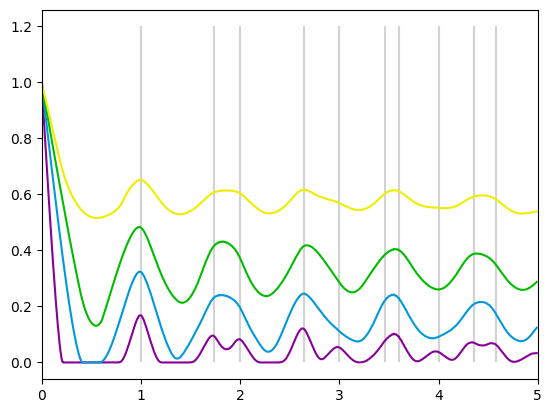

In [46]:
distance=100

def hexagonal_s(n,m):
    return (n**2+n*m+m**2)**0.5

for i in range(5):
    for j in range(5):
        plt.vlines(hexagonal_s(i,j),0,1.2,color='lightgrey')
        
plt.plot(np.arange(len(showcase4[0]))/distance,showcase4[plots[0]],label='radius=1',color=colors[0])
plt.plot(np.arange(len(showcase4[0]))/distance,showcase4[plots[1]],label='radius=10',color=colors[1])
plt.plot(np.arange(len(showcase4[0]))/distance,showcase4[plots[2]],label='radius=20',color=colors[2])
plt.plot(np.arange(len(showcase4[0]))/distance,showcase4[plots[3]],label='radius=30',color=colors[3])

plt.xlim(0,5)



{0.0,
 3.3333333333333335,
 5.773502691896257,
 6.666666666666667,
 8.81917103688197,
 10.0,
 11.547005383792515,
 12.01850425154663,
 13.333333333333334,
 14.529663145135581,
 15.275252316519467,
 17.320508075688775,
 17.63834207376394,
 20.275875100994064,
 23.09401076758503}

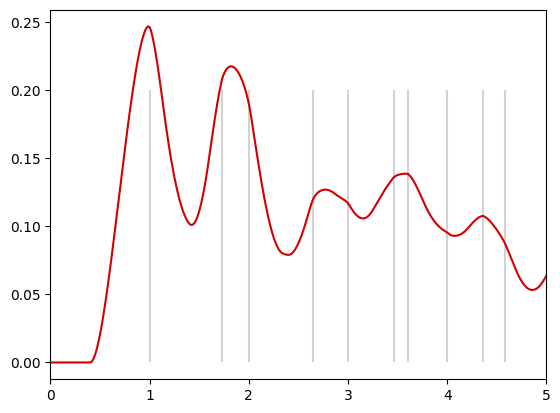

In [136]:
def hexagonal_s(n,m):
    return (n**2+n*m+m**2)**0.5

cell_radius = 0.3

ss = []

for i in range(5):
    for j in range(5):
        ss.append(hexagonal_s(i,j)/cell_radius)
     
ss=set(ss)
ds = np.linspace(0, len(showcase4[0])/cell_radius/distance, len(showcase4[0]))

values = np.zeros((len(ds),))

for i,s in enumerate(ss):
    plt.vlines(s*cell_radius,0,0.2,color='lightgrey')
    if s>0:
        color = nipy_spectral(i/len(ss))
        
        d=s
        max_theta = np.arccos(max(-1,((s**2+d**2-1)/(2*s*d))))
        thetas = np.linspace(0, max_theta*2, 30)
        
        Thetas, Ds  = np.meshgrid(thetas, ds )
        
        values += np.nan_to_num(a_function(Thetas,s,Ds)).mean(1)/np.pi**2*max_theta*6
plt.plot(ds*cell_radius,values,color=color,label=s) # Assuming d=1 for example
#     maxs[i]=values.argmax()

plt.xlim(0,5)
ss

/tmp/ipykernel_2848041/3544822155.py:27: RuntimeWarning: invalid value encountered in multiply
  vol = 16 * ((2 - m_values) * E_values - 2 * (1 - m_values) * K_values)


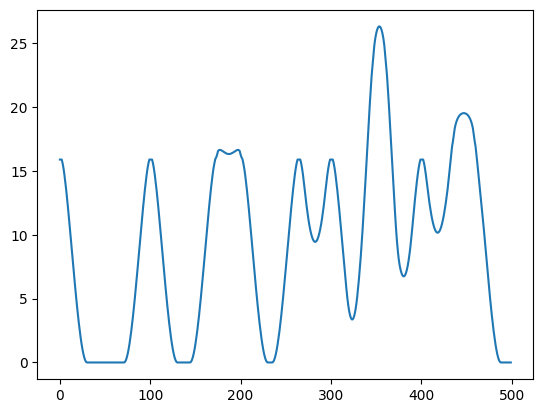

In [ ]:
model_hex_cooc = np.zeros((len(showcase4[0]),))
def hexagonal_s(n,m):
    return (n**2+n*m+m**2)**0.5

volume_values = volume(np.linspace(0,1,30))

for i in range(5):
    for j in range(5):
        idx = int(distance*hexagonal_s(i,j))
        if idx<len(model_hex_cooc):
            model_hex_cooc[idx]=1
        
convolved = scipy.signal.fftconvolve(model_hex_cooc,volume_values,mode='same')       

plt.plot(convolved) 
        

(0.0, 7.35)

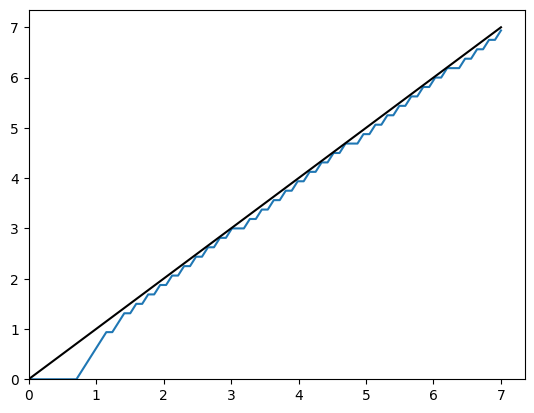